In [1]:
import pandas as pd
import geopandas as gpd
import xarray as xr
import numpy as np

import string
import windrose
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

from metpy.calc import wind_direction,wind_speed
from metpy.units import units

from cmcrameri import cm

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = [
    'Helvetica',
    'Nimbus Sans',
    'Arial',
    'Liberation Sans'
]

data_dir = '../data_out/'
fig_png_dir = '../figures_png/'
fig_pdf_dir = '../figures_pdf/'

In [2]:
def get_df_from_nc(file, var, loc_sel=None):
    ds = xr.open_dataset(file)
    time_dim = ds[var].dims[0]
    df = pd.DataFrame(ds[var].values, columns=ds.location, index=pd.to_datetime(ds[time_dim],utc=True))
    if loc_sel is None:
        return df
    else:
        return df[loc_sel]

def get_mean_timeframe(str_from, str_to):
    def add_to_output(df_in, mask, col_name):
        s_cnt = df_in.where(mask)[dt_from:dt_to].count()
        s_mean = df_in.where(mask)[dt_from:dt_to].mean()
        s_mean[s_cnt<12]=np.nan
        s_mean.name = col_name
        return pd.merge(df_out, s_mean, left_on='loc', right_index=True, how='left')
        
    dt_from = pd.to_datetime(str_from, utc=True)
    dt_to   = pd.to_datetime(str_to, utc=True)

    df_out = df_loc.copy()
    
    df_out = add_to_output(df_temp,   temp_mask, 'temp_o')
    df_out = add_to_output(df_i_temp, temp_mask, 'temp_i')

    df_out = add_to_output(df_u,   wind_mask, 'u_o')
    df_out = add_to_output(df_v,   wind_mask, 'v_o')
    df_out = add_to_output(df_i_u, wind_mask, 'u_i')
    df_out = add_to_output(df_i_v, wind_mask, 'v_i')
    
    return df_out

## Script settings

In [3]:
loc_temp = ['D316','A309','D305','T303','D293','D285','D281','T275','D269','A267','A267R','A267L','A260','A255','STHE']
loc_wind = ['D316','A309','T303', 'D293', 'D281','T275','D269','A267','A267L','A267R','A260','A255', 'STHE' ]

use_avg_wind = True

## Read data

The data used for this figure is available at Zenodo:

[![DOI](https://zenodo.org/badge/DOI/10.5281/zenodo.19568035.svg)](https://doi.org/10.5281/zenodo.19568035)

In [4]:
# get outline of Hintereisferner (HEF)
rgi = gpd.read_file('../data_in/Glacier_Outlines_v370_2030_smoothed.geojson')
rgi_hef = rgi.loc[rgi['rgi_id'] == 'RGI60-11.00897']

In [5]:
file_obs  = f'HEFEX2__Obs_AWS_L1__1h_avg30min_20230816-20230910.nc'
file_icon = f'HEFEX2__ICON_v370_2030_aws_locations__1h_avg30min_20230815-20230914.nc'

In [6]:
# get locations with coords
ds = xr.open_dataset(data_dir + file_obs)

df_loc = pd.DataFrame()
df_loc['loc'] = ds.location.values
df_loc['lon'] = ds.lon.values
df_loc['lat'] = ds.lat.values

In [7]:
def get_wind_for_loc(file, suf, loc_str):
    df_u = get_df_from_nc(data_dir + file, f'u{suf}', [loc_str])
    df_v = get_df_from_nc(data_dir + file, f'v{suf}', [loc_str])

    df_out = pd.DataFrame(index=df_u.index)
    df_out['ws'] = wind_speed(df_u[loc_str].values * units('m/s'), df_v[loc_str].values * units('m/s'))
    df_out['wd'] = wind_direction(df_u[loc_str].values * units('m/s'), df_v[loc_str].values * units('m/s'))
    return df_out

In [8]:
# get temp data
df_temp   = get_df_from_nc(data_dir + file_obs,  't_2m')
df_i_temp = get_df_from_nc(data_dir + file_icon, 't_5m') - 273.15

# get wind vectors (surface)
if use_avg_wind: 
    avg_suf = '_avg'  # get 30min avg wind
else: 
    avg_suf = ''      # inst wind at full hour
    
df_u = get_df_from_nc(data_dir + file_obs, f'u{avg_suf}')
df_v = get_df_from_nc(data_dir + file_obs, f'v{avg_suf}')

df_i_u = get_df_from_nc(data_dir + file_icon, f'u_5m{avg_suf}')
df_i_v = get_df_from_nc(data_dir + file_icon, f'v_5m{avg_suf}')

# calculate wind speed and direction at location T275 for wind rose plots
df_wind_o = get_wind_for_loc(file_obs, f'{avg_suf}', 'T275')
df_wind_i = get_wind_for_loc(file_icon, f'_5m{avg_suf}', 'T275')
df_wind_i_500 = get_wind_for_loc(file_icon, f'_500hPa', 'T275')

# get masks for valid records (= Observation and ICON data_in available)
temp_mask = df_temp.notna() & df_i_temp.notna()
wind_mask = df_u.notna() & df_v.notna() & df_i_u.notna() & df_i_v.notna()

In [12]:
def add_minmax_text(ax, s):
    # ax.text(0.01, 0.90,
    ax.text(0.01, 0.01,
            fr"$T_{{min}}={s.min():.2f}$ °C"
            "\n"
            fr"$T_{{max}}={s.max():.2f}$ °C", 
            transform=ax.transAxes,
            fontsize=8, ha="left", va="bottom")

def add_daterange_text(ax, date_range_str, h):
    ax.text(0.01,0.99, date_range_str,transform=ax.transAxes,ha="left", va="top")
    rect = Rectangle(
        (0.00, 1-h ),0.26, h,
        # (0.00, 1-.06 ),0.25, 0.06,
        transform=ax.transAxes,
        edgecolor="black",facecolor="whitesmoke",lw=.1, zorder=-20
    )
    ax.add_patch(rect)

def plot_maps(ax_i, ax_o, str_from, str_to):
    def add_data_and_text(ax, col_temp, col_u, col_v, h=.07):
        add_daterange_text(ax, date_range_str, h)
        add_minmax_text(ax, df_temp[col_temp])
        ax.scatter(df_temp['lon'], df_temp['lat'], c=df_temp[col_temp], cmap=cmap, norm=norm, s=16)
        ax.barbs(df_wind['lon'], df_wind['lat'], df_wind[col_u], df_wind[col_v], barb_increments=bi, length=4.5, lw=.5, pivot='tip')

    def add_windrose(ax, df, title, cmap, bins, bta):
        df = df.loc[dt_from:dt_to].dropna()
        wrax = inset_axes(
            ax, width=.9, height=.9,
            loc="center", bbox_to_anchor=bta,
            bbox_transform=ax.transData,
            axes_class=windrose.WindroseAxes,
        )
        wrax.bar(df.wd, df.ws, normed=True, opening=0.9, cmap=cmap, bins=bins)
        wrax.grid(alpha=.3)
        wrax.grid(axis='y')
        wrax.tick_params(labelleft=False, labelbottom=True, labelsize=6, pad=-5)
        # wrax.set_legend()
        return wrax

    dt_from = pd.to_datetime(str_from, utc=True)
    dt_to   = pd.to_datetime(str_to, utc=True)
    
    # get plot data_in (filtering on given time frame and selected locations for temp/wind)
    date_range_str = dt_from.strftime('%d.-') + dt_to.strftime('%d. %b %Y')
    print(date_range_str)
    df_data = get_mean_timeframe(str_from, str_to)
    df_temp = df_data[df_data['loc'].isin(loc_temp)]
    df_wind = df_data[df_data['loc'].isin(loc_wind)]
    #df_500_tmp = df_wind_o.loc[dt_from:dt_to]

    #-- Left Panel
    # Observation Data
    add_data_and_text(ax_o, 'temp_o', 'u_o', 'v_o')

    
    #-- Right Panel
    # ICON Data
    add_data_and_text(ax_i, 'temp_i', 'u_i', 'v_i', h=.475)
    #ax=ax_o

    # Plot the windrose on additional axis
    add_windrose(ax_o, df_wind_o, 'T275 2m', cm.acton, np.arange(0, 6, 1), bta=(10.7895, 46.791))
    add_windrose(ax_i, df_wind_i, 'T275 5m', cm.acton, np.arange(0, 6, 1), bta=(10.7895, 46.791))
    wrax = add_windrose(ax_i, df_wind_i_500, '500 hPa level', cm.tokyo, np.arange(0, 16, 3), bta=(10.732, 46.8095))
    wrax.text(.5,.35, '500 hPa\nlevel',ha="center", va="top", fontsize=8, transform=wrax.transAxes)



    # def horizontal_arrow_label(ax, lon0, lon1, lat, label, offset=0, **arrow_kw):
    #
    #     ax.annotate(
    #         "", xy=(lon1, lat), xytext=(lon0, lat),
    #         arrowprops=dict(arrowstyle="-[", lw=.4, ec='grey', fc='grey', mutation_scale=30, **arrow_kw)
    #     )
    #
    #     ax.text(
    #         (lon0 + lon1)/2, lat + offset, label,
    #         ha="center", va="bottom", fontsize=8, color='grey'
    #     )
    #
    # horizontal_arrow_label(ax_i, 10.7713, 10.78, 46.8, 'T275')
    # horizontal_arrow_label(ax_o, 10.7713, 10.78, 46.8004, 'T275')

In [10]:
def get_discrete_cmap(cmap, bins, extend='neither'):
    cmap = plt.get_cmap(cmap, len(bins)-1)
    norm = BoundaryNorm(bins, cmap.N, extend=extend)
    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    return cmap, norm, sm

20.-25. Aug 2023
29.-30. Aug 2023
04.-07. Sep 2023


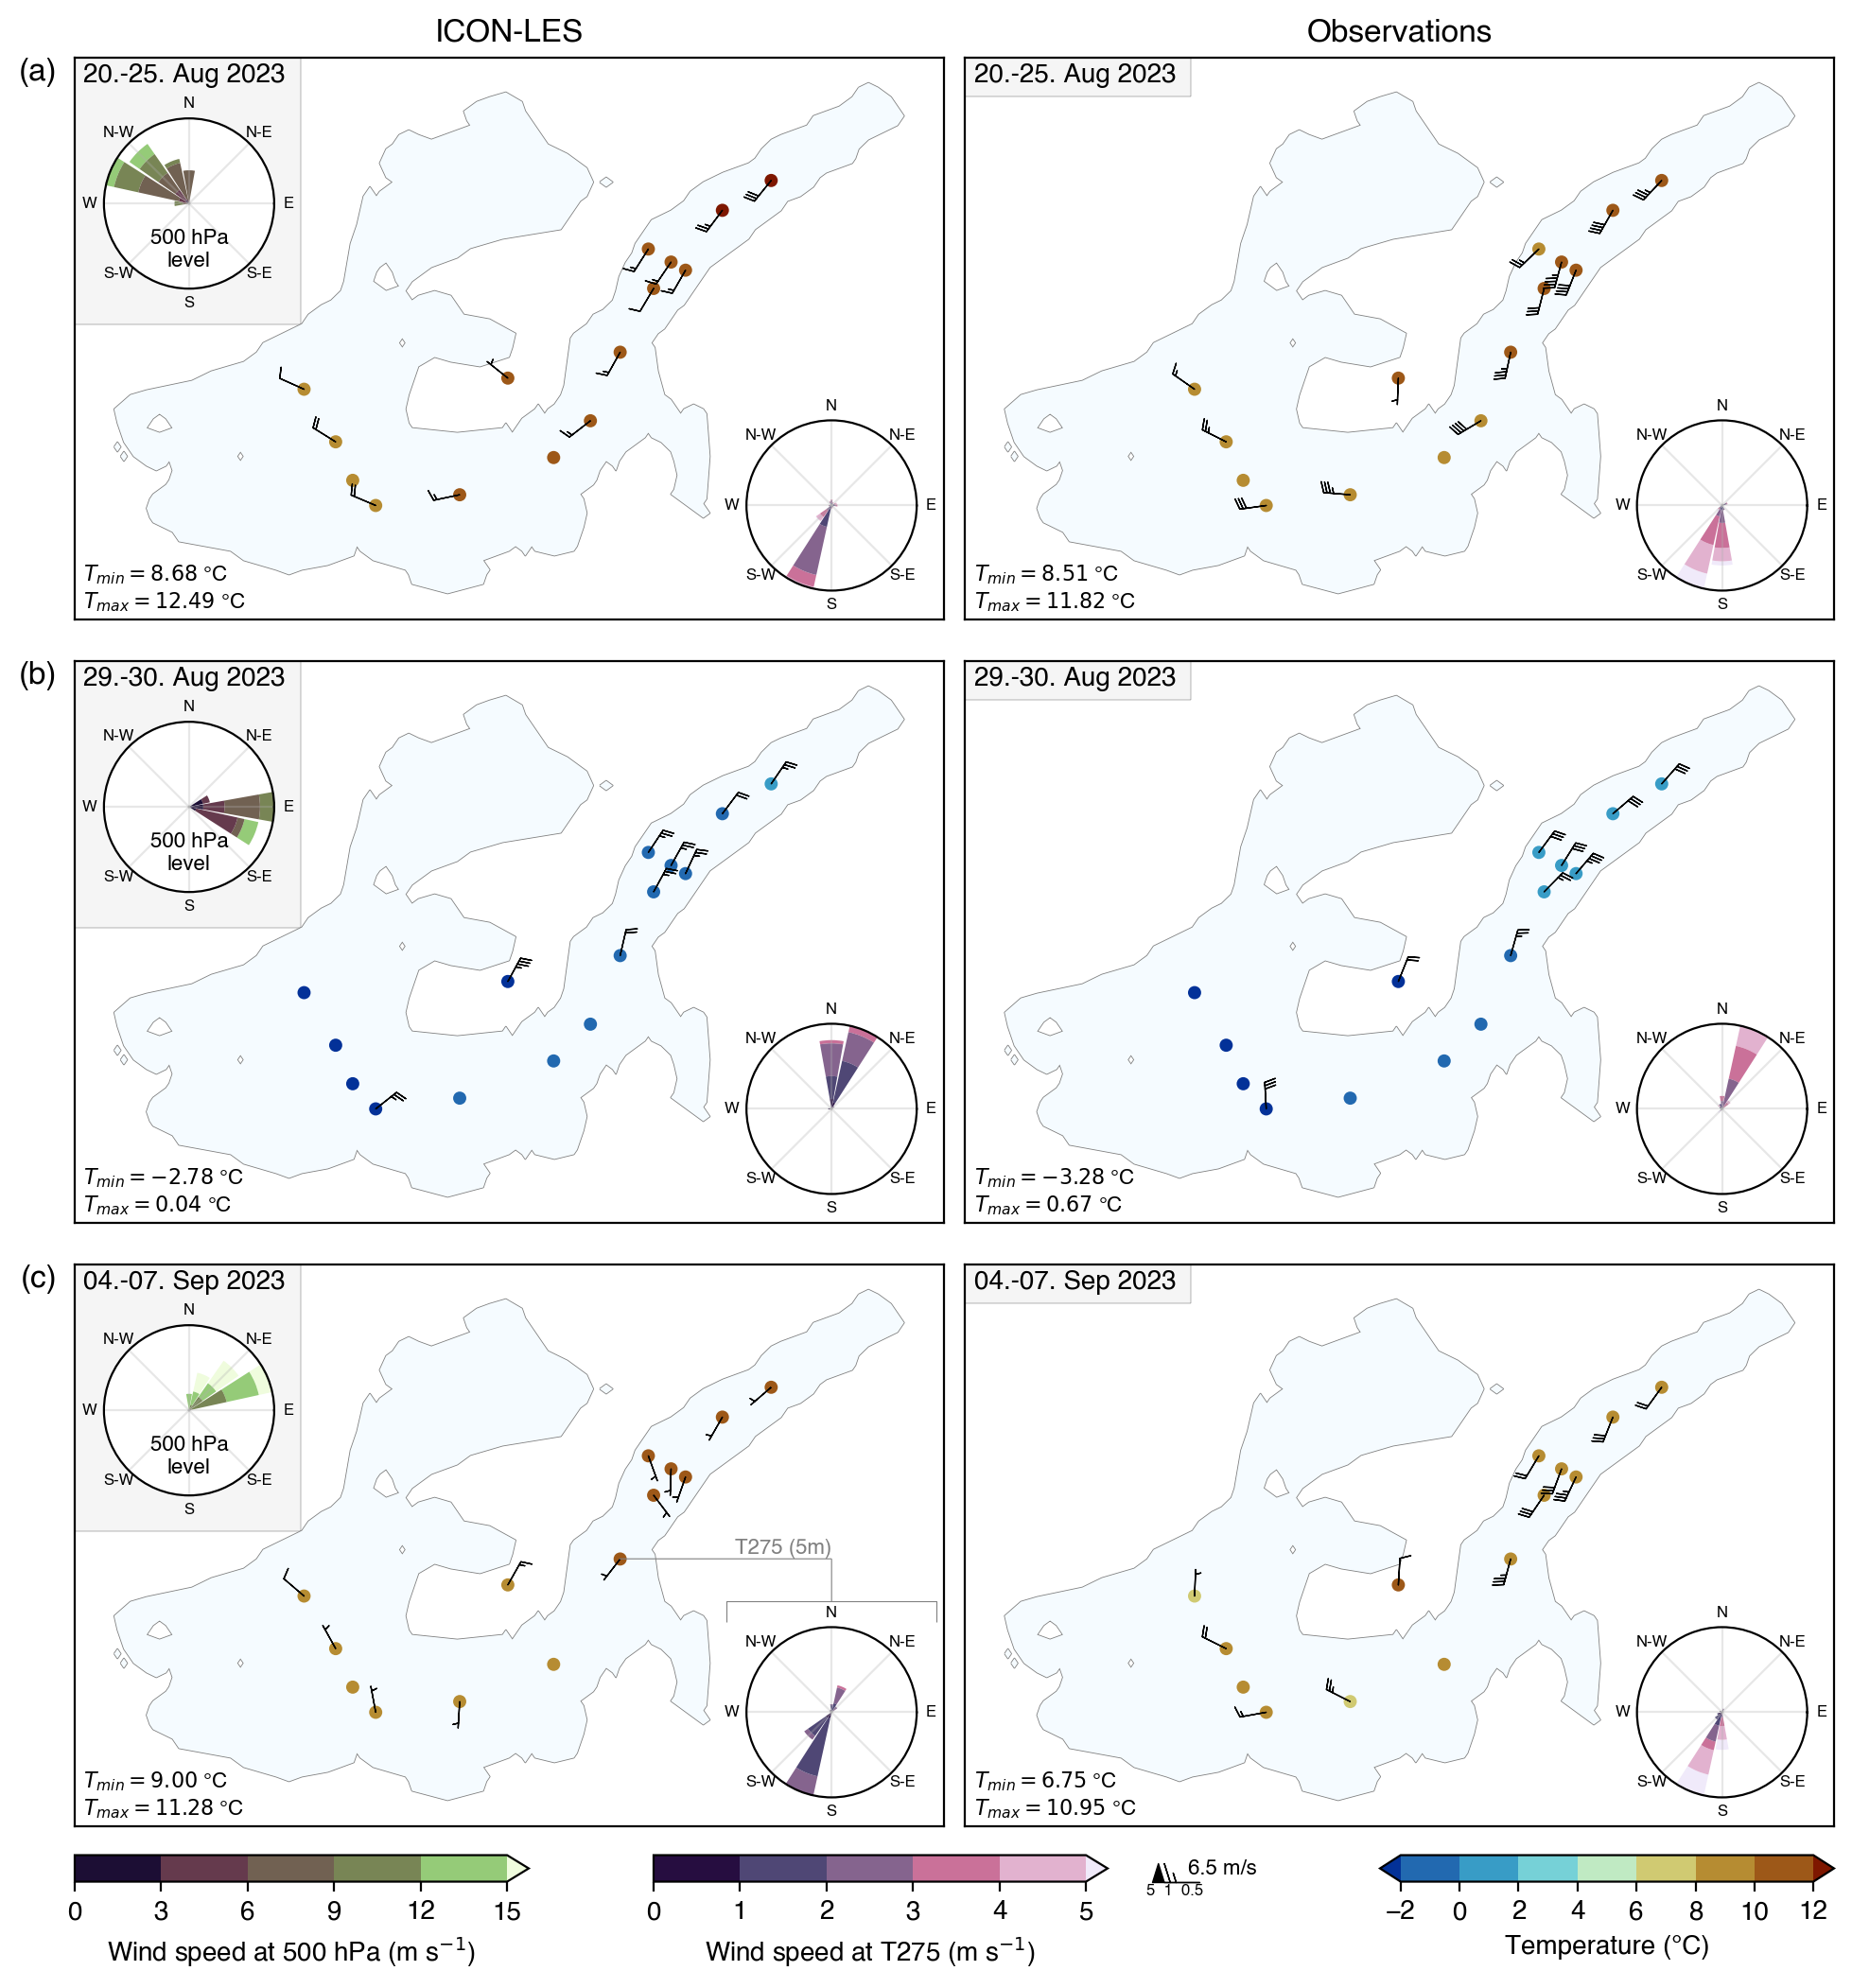

In [30]:
#bi = dict(half=2.57222, full=5.144, flag=25.7222)
# bi = dict(half=1, full=2, flag=10)
bi = dict(half=.5, full=1, flag=5)


cmap, norm, sm = get_discrete_cmap(cm.roma_r, range(-2,13,2), 'both')

fig, axs = plt.subplots(ncols=2, nrows=3, figsize=(12,14), sharex=True, sharey=True, dpi=200,
                        gridspec_kw={'hspace': -0.275, 'wspace': 0.025})

# base map with glacier
for ax in axs.flatten():
    rgi_hef.boundary.plot(ax=ax, lw=.6, color='grey', zorder=-10)
    rgi_hef.plot(ax=ax, color='#f5fbff',alpha=1)

# data_in for defined time frames
plot_maps(axs[0][0], axs[0][1], '2023-08-20', '2023-08-25')
plot_maps(axs[1][0], axs[1][1], '2023-08-29', '2023-08-30')
plot_maps(axs[2][0], axs[2][1], '2023-09-04', '2023-09-07')

# add column titles
axs[0][0].set_title('ICON-LES')
axs[0][1].set_title('Observations')

# remove tick labels
for ax in axs.flat:
    ax.set_xticks([])
    ax.set_yticks([])


cax1 = fig.add_axes([0.125, 0.14, 0.2, 0.01])
cax2a = fig.add_axes([0.38, 0.14, 0.2, 0.01])
cax2b = fig.add_axes([0.59, 0.13, 0.04, 0.02])
cax3 = fig.add_axes([0.70, 0.14, 0.2, 0.01])

# colorbar for temperature
fig.colorbar(sm, cax=cax3, orientation="horizontal", label='Temperature (°C)')


# build discrete colormaps for windroses
_,_,sm = get_discrete_cmap(cm.tokyo, np.arange(0,16,3), extend='max')
fig.colorbar(sm, cax=cax1, orientation="horizontal", label='Wind speed at 500 hPa (m s$^{-1}$)', extend="max")

_,_,sm = get_discrete_cmap(cm.acton, np.arange(0,6,1), extend='max')
fig.colorbar(sm, cax=cax2a, orientation="horizontal", label='Wind speed at T275 (m s$^{-1}$)', extend="max")

cax2b.barbs(0,0, sum(bi.values()),0, barb_increments=bi, length=6, lw=.5, pivot='middle')
cax2b.text(0.015, 0.005, f'{sum(bi.values())} m/s', ha='left', va='bottom', fontsize=8)
cax2b.text(-0.035, -0.0055, f'5  1  0.5', ha='left', va='top', fontsize=6)
cax2b.set_axis_off()

# panel letters 
for ax, letter in zip(axs[:, 0], string.ascii_lowercase):
    ax.text(
        -0.02, 1, f'({letter})',
        transform=ax.transAxes,
        fontsize=12, fontweight='bold',
        va='top', ha='right'
    )


lon0,lat0 = 10.7705, 46.8004
lon1,lat1 = 10.7895, 46.7978

ax.annotate(
    "", xy=(lon1, lat0), xytext=(lon0, lat0),
    arrowprops=dict(arrowstyle="-", lw=.4, ec='grey', fc='grey',shrinkA=0,shrinkB=0,capstyle="butt", zorder=-5),
)
ax.annotate(
    "", xy=(lon1, lat1), xytext=(lon1, lat0),
    arrowprops=dict(arrowstyle="-[", lw=.4, ec='grey', fc='grey', mutation_scale=40,shrinkA=0,shrinkB=0,capstyle="butt")
)

# ax.text(
#     (lon0 + lon1)/2, lat0, 'T275 (5m)',
#     ha="center", va="bottom", fontsize=8, color='grey'
# )
ax.text(
    lon1, lat0, 'T275 (5m)',
    ha="right", va="bottom", fontsize=8, color='grey'
)

# save and show
# plt.savefig(fig_png_dir + f'HEF_AWS_ICON_windmap_v2.png', dpi=150, bbox_inches = 'tight', pad_inches = 0)
# plt.savefig(fig_pdf_dir + f'HEF_AWS_ICON_windmap_v2.pdf', dpi=300, bbox_inches = 'tight', pad_inches = 0)
plt.show()